In [1]:
# Run this cell to set up packages for lecture.
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

path = 'lectures/lec09'
if not Path("data").exists():
    !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
    !unzip -q -o /content/course.zip "cosmos-ml-cluster-2026-main/{path}/data/*" -d /content/course-assets
    !cp -R /content/course-assets/cosmos-ml-cluster-2026-main/{path}/data .

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.linewidth': 1.5,
    'grid.color': '#999999',
    'grid.alpha': 0.35,
    'font.weight': 'bold',
    'legend.fontsize': 11,
})

pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)
pd.set_option('display.precision', 3)


# Lecture 9 - Decision Trees, Random Forests, and Logistic Regression

## COSMOS ML Cluster 2026


### Agenda

- Decision trees.
- Tree depth and overfitting.
- Grid-search cross-validation.
- Bootstrap sampling and random forests.
- Logistic regression.
- Choosing a final model.


### Learning goals

By the end of today, you should be able to:

- Trace how a decision tree makes a prediction.
- Explain how tree depth affects model complexity.
- Use `GridSearchCV` to compare hyperparameter combinations.
- Explain how a bootstrap sample is created.
- Describe how a random forest combines many decision trees.
- Use cross-validation to choose among k-NN, random forest, and logistic regression.


## Diabetes Prediction

Today, we will use two measurements to predict whether a patient has diabetes:

- glucose level;
- body mass index, or BMI.


In [2]:
diabetes = pd.read_csv(Path('data') / 'diabetes.csv')
diabetes.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


The response column is `Outcome`:

- `0` means no diabetes;
- `1` means diabetes.


In [3]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split

feature_names = ['Glucose', 'BMI']
X = diabetes[feature_names]
y = diabetes['Outcome']

# Keep the test data untouched until the very end of the lecture.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

folds = KFold(n_splits=5, shuffle=True, random_state=42)

print(f'Training patients: {len(X_train)}')
print(f'Test patients kept hidden: {len(X_test)}')


Training patients: 576
Test patients kept hidden: 192


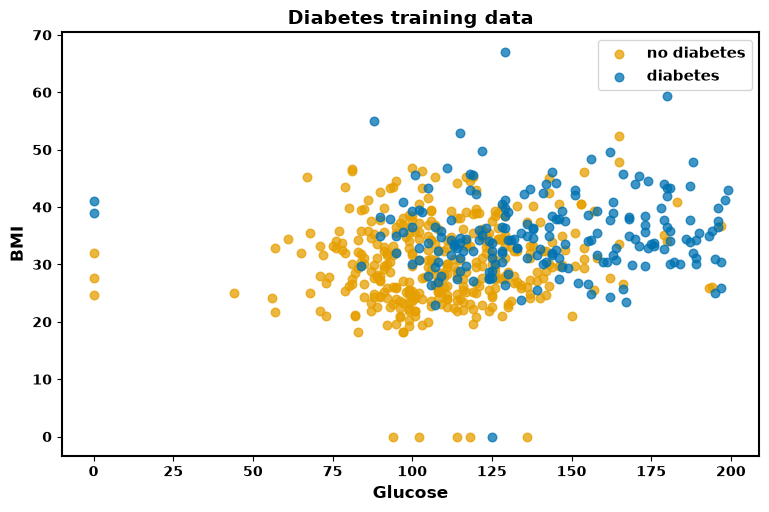

In [4]:
class_names = ['no diabetes', 'diabetes']
class_colors = {0: '#e69f00', 1: '#0072b2'}


def scatter_diabetes(X_data, y_data, ax, title=None, alpha=0.75):
    for outcome, label in enumerate(class_names):
        points = X_data.loc[y_data == outcome]
        ax.scatter(
            points['Glucose'], points['BMI'],
            s=38, alpha=alpha, color=class_colors[outcome], label=label
        )
    ax.set(xlabel='Glucose', ylabel='BMI', title=title)
    ax.legend()


def plot_decision_boundary(model, X_data, y_data, ax, title):
    glucose_values = np.linspace(
        X_data['Glucose'].min() - 3, X_data['Glucose'].max() + 3, 220
    )
    bmi_values = np.linspace(
        X_data['BMI'].min() - 2, X_data['BMI'].max() + 2, 220
    )
    gg, bb = np.meshgrid(glucose_values, bmi_values)
    grid = pd.DataFrame({'Glucose': gg.ravel(), 'BMI': bb.ravel()})
    predictions = model.predict(grid).reshape(gg.shape)

    ax.contourf(
        gg, bb, predictions,
        levels=[-0.5, 0.5, 1.5],
        colors=['#fff0c7', '#dcecf7'], alpha=0.85
    )
    scatter_diabetes(X_data, y_data, ax, title=title, alpha=0.6)


fig, ax = plt.subplots(figsize=(9, 5.5))
scatter_diabetes(X_train, y_train, ax, 'Diabetes training data')
plt.show()


## Decision trees 🌲

A decision tree makes a classification by asking a series of yes/no questions.

For example:

```text
Is glucose above a particular value?
  ├── Yes → Is BMI above a particular value? → prediction
  └── No  → Is BMI above a different value?  → prediction
```


### Building a decision tree

We fit a decision tree just like the classifiers we have already seen.

`max_depth=2` limits the tree to at most two layers of questions.


In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(
    max_depth=2,
    criterion='entropy',
    random_state=42,
)
tree.fit(X_train, y_train);


### Visualizing a decision tree

- An **internal node** asks a question.
- A **branch** represents an answer.
- A **leaf node** makes a prediction.
- `value` counts the training patients from each class that reached that node.


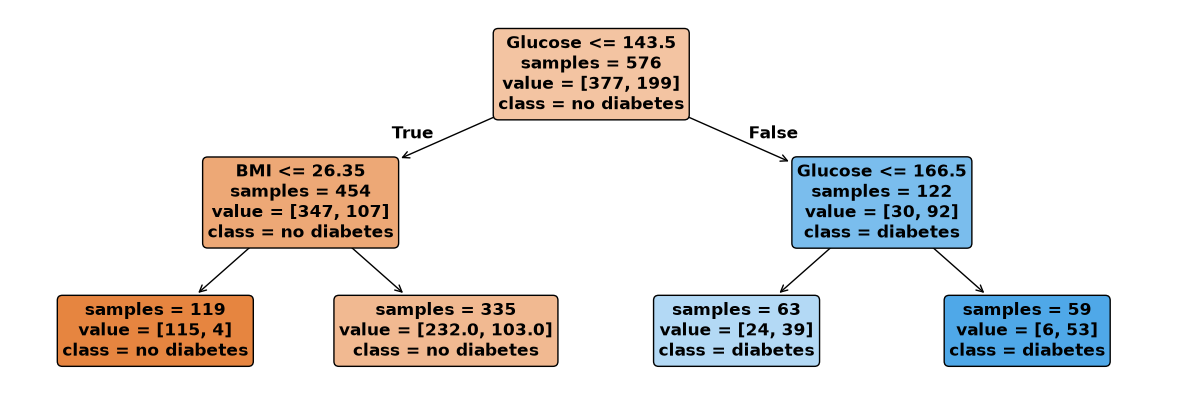

In [6]:
plt.figure(figsize=(15, 5))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=12,
);


### Following a patient through the tree

Start at the root and answer its question.

- If the answer is **yes**, follow the left branch.
- If the answer is **no**, follow the right branch.
- Continue until reaching a leaf.


In [7]:
new_patient = pd.DataFrame({'Glucose': [150], 'BMI': [35]})
predicted_outcome = tree.predict(new_patient)[0]

display(new_patient)
print('Prediction:', class_names[predicted_outcome])


,Glucose,BMI
0,150,35


Prediction: diabetes


## The `.score()` method

For a classifier, `.score()` returns its accuracy.

It works on any labeled collection of rows, including the training data or a validation fold.


In [8]:
tree.score(X_train, y_train)


0.7621527777777778

### Concept Check ✅

A patient reaches a leaf with `value = [18, 52]`.

1. How many training patients reached this leaf?
2. Which class will the tree predict?
3. Would the prediction change for a second patient who reaches the same leaf?


## How are decision trees trained?

At each node, the training process:

1. considers many possible questions involving the available features;
2. selects the best question;
3. separates the rows according to their answers;
4. repeats within each resulting group.


### Training pseudocode

```python
def make_tree(X, y):
    if this node should stop:
        return a leaf that predicts the most common class

    feature, value = best_question(X, y)
    left = make_tree(rows where feature <= value)
    right = make_tree(rows where feature > value)
    return a node containing the question, left, and right
```


## How do we measure the quality of a split?

Suppose a node contains:

🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵🔵

**Split A**

- Yes: 🟠🟠🟠🔵🔵🔵
- No: 🟠🟠🟠🔵🔵🔵

**Split B**

- Yes: 🔵🔵🔵🔵🔵
- No: 🔵🟠🟠🟠🟠🟠🟠

Which split is better?


Split B is better because it more **cleanly separates** the two classes.

Decision-tree training quantifies this idea using a metric called **entropy** and chooses the split that minimizes it. We won't get into the entropy calculation right now, but you can [check out this blog post](https://medium.com/data-science/entropy-how-decision-trees-make-decisions-2946b9c18c8) if you're curious.


## Tree depth

A decision tree recursively asks more questions until it reaches a stopping condition.

By default, a tree has no maximum depth. It can keep asking questions until its leaves are extremely specific to the training data.


In [9]:
unrestricted_tree = DecisionTreeClassifier(
    criterion='entropy', random_state=42
)
unrestricted_tree.fit(X_train, y_train)

print('Tree depth:', unrestricted_tree.tree_.max_depth)


Tree depth: 25


The unrestricted tree looks excellent on familiar training patients—but that does not mean it will work well on new patients.


In [10]:
print('Depth-2 training accuracy:', tree.score(X_train, y_train))
print('Unrestricted training accuracy:', unrestricted_tree.score(X_train, y_train))


Depth-2 training accuracy: 0.7621527777777778
Unrestricted training accuracy: 0.9965277777777778


In [11]:
depth_2_cv = cross_val_score(tree, X_train, y_train, cv=folds)
unrestricted_cv = cross_val_score(
    unrestricted_tree, X_train, y_train, cv=folds
)

depth_comparison = pd.DataFrame({
    'model': ['Depth 2', 'Unrestricted'],
    'training accuracy': [
        tree.score(X_train, y_train),
        unrestricted_tree.score(X_train, y_train),
    ],
    'mean validation accuracy': [
        depth_2_cv.mean(),
        unrestricted_cv.mean(),
    ],
}).set_index('model')
depth_comparison


,training accuracy,mean validation accuracy
model,,
Depth 2,0.762,0.727
Unrestricted,0.997,0.701


### Decision trees and overfitting

A deep tree can ask enough questions to memorize details and noise in the training sample.

Limiting the depth makes the tree less complex and can improve its predictions on unseen data.


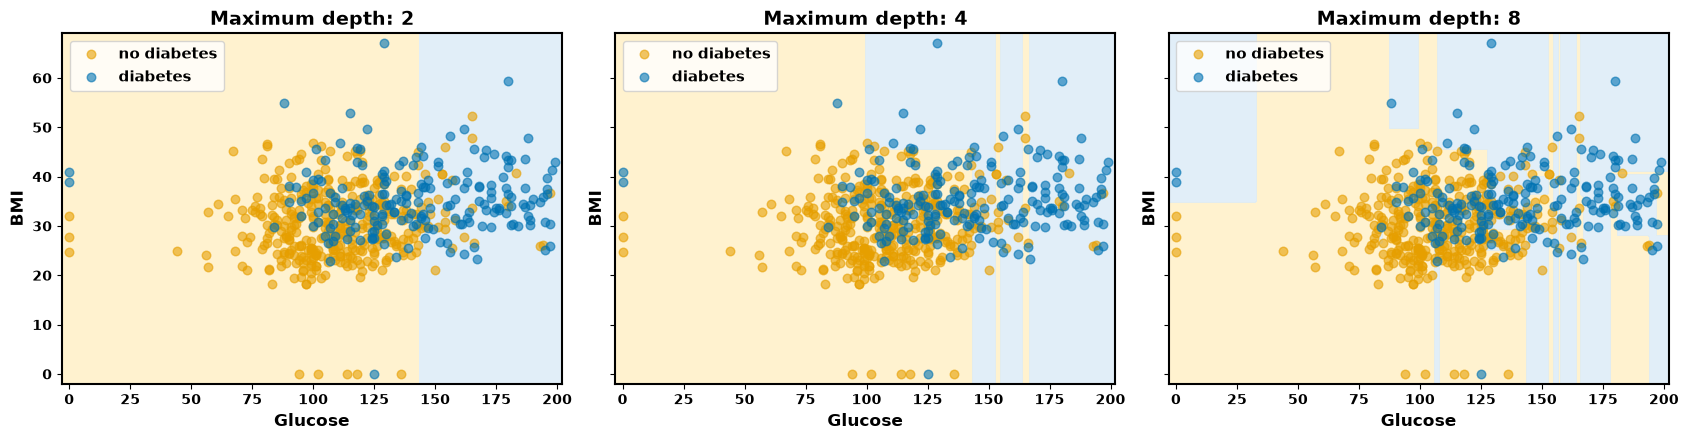

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharex=True, sharey=True)

for depth, ax in zip([2, 4, 8], axes):
    model = DecisionTreeClassifier(
        max_depth=depth,
        criterion='entropy',
        random_state=42,
    ).fit(X_train, y_train)
    plot_decision_boundary(
        model, X_train, y_train, ax, f'Maximum depth: {depth}'
    )

plt.tight_layout()
plt.show()


### Concept Check ✅

As maximum tree depth increases:

1. What usually happens to training accuracy?
2. What happens to the complexity of the decision boundary?
3. Why might validation accuracy eventually decrease?


## Hyperparameters for decision trees

Two useful settings are:

- `max_depth`: the maximum number of layers of questions;
- `min_samples_split`: the minimum number of training rows required to split a node.

How should we choose a combination of values?


## Grid-search cross-validation

Previously, we wrote loops that used cross-validation to compare many choices.

`GridSearchCV` performs that work for us: it tries every listed hyperparameter combination and finds the combination with the best mean validation score.


In [13]:
from sklearn.model_selection import GridSearchCV

parameter_grid = {
    'max_depth': [2, 3, 4, 5, 7, 10, None],
    'min_samples_split': [2, 10, 25, 50],
}
parameter_grid


{'max_depth': [2, 3, 4, 5, 7, 10, None], 'min_samples_split': [2, 10, 25, 50]}

We must find the best **combination**, not the best value for each setting separately.


In [14]:
combinations = (
    len(parameter_grid['max_depth'])
    * len(parameter_grid['min_samples_split'])
)
print('Hyperparameter combinations:', combinations)
print('Models fit during 5-fold CV:', combinations * 5)


Hyperparameter combinations: 28
Models fit during 5-fold CV: 140


In [15]:
tree_search = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    parameter_grid,
    cv=folds,
)
tree_search.fit(X_train, y_train);


### Results of the search

After fitting:

- `best_params_` contains the winning combination;
- `best_score_` contains its mean validation accuracy;
- `best_estimator_` is a tree with that combination, refit on all training rows.


In [16]:
print('Best parameters:', tree_search.best_params_)
print('Best mean validation accuracy:', tree_search.best_score_)
print('Best estimator:', tree_search.best_estimator_)


Best parameters: {'max_depth': None, 'min_samples_split': 50}
Best mean validation accuracy: 0.7343328335832083
Best estimator: DecisionTreeClassifier(criterion='entropy', min_samples_split=50,
                       random_state=42)


In [17]:
grid_results = pd.DataFrame(tree_search.cv_results_)
grid_results[
    ['param_max_depth', 'param_min_samples_split',
     'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).head(8)


,param_max_depth,param_min_samples_split,mean_test_score,std_test_score
27,None,50,0.734,0.045
16,7,2,0.734,0.044
19,7,50,0.734,0.049
8,4,2,0.734,0.045
4,3,2,0.733,0.041
5,3,10,0.733,0.041
6,3,25,0.733,0.041
7,3,50,0.733,0.041


### Choosing the grid

A large grid can take a long time because every combination is fit once per fold.

A useful rule of thumb: start with a reasonable range of parameters to search over. Then, if the winning value is at an edge, expand the grid in that direction.


### Concept Check ✅

A grid contains:

- 6 choices for `max_depth`;
- 4 choices for `min_samples_split`;
- 2 choices for another hyperparameter.

How many models are fit during 5-fold grid-search cross-validation?


## Decision tree strengths and weaknesses

**Strengths**

- Predictions can be traced through understandable questions.
- Trees can learn complicated, non-linear boundaries.
- Changing a feature's units does not change the ordering used by a split.

**Weaknesses**

- Deep trees easily overfit.
- Small changes to the training sample can produce a different tree.


## Random forests 🌲🌲🌲

What if we train many different decision trees and let them **vote** on each prediction?

If every tree sees exactly the same data and follows the same procedure, the trees will be too similar. A random forest deliberately adds randomness.


## Bootstrap sampling

A **bootstrap sample** is created by drawing rows:

- at random;
- **with replacement**;
- until the new sample has the same number of rows as the original.

“With replacement” means a row can be selected more than once.


In [18]:
tiny_training_set = pd.DataFrame({
    'row': list('ABCDEFGH'),
    'class': ['orange', 'blue', 'orange', 'orange',
              'blue', 'blue', 'orange', 'blue'],
})
tiny_training_set


,row,class
0,A,orange
1,B,blue
2,C,orange
3,D,orange
4,E,blue
5,F,blue
6,G,orange
7,H,blue


In [19]:
bootstrap_sample = tiny_training_set.sample(
    n=len(tiny_training_set),
    replace=True,
    random_state=7,
).reset_index(drop=True)
bootstrap_sample.index = np.arange(1, len(bootstrap_sample) + 1)
bootstrap_sample.index.name = 'draw number'
bootstrap_sample


,row,class
draw number,,
1,H,blue
2,E,blue
3,B,blue
4,G,orange
5,D,orange
6,D,orange
7,H,blue
8,H,blue


In [20]:
selected_rows = set(bootstrap_sample['row'])
original_rows = set(tiny_training_set['row'])

print('Rows selected more than once:')
display(bootstrap_sample['row'].value_counts().loc[lambda s: s > 1])
print('Rows not selected:', sorted(original_rows - selected_rows))


Rows selected more than once:


row
H    3
D    2
Name: count, dtype: int64

Rows not selected: ['A', 'C', 'F']


### Concept Check ✅

An original training set has 100 rows. We make one bootstrap sample.

1. How many draws are made?
2. Can one original row appear three times?
3. Must every original row appear at least once?


## From bootstrap samples to a forest

We can create many bootstrap samples and train one decision tree on each.

This is called **bagging**, short for **bootstrap aggregating**.

Different bootstrap samples help produce different trees, but it turns out the trees are not different "enough" to make the classifier perform better, since 1-2 very strong features may still cause every tree to begin with the same splits.


### A second source of randomness

So we need a second way to decorrelate the trees: at each split, a random forest lets the tree consider only a random subset of the available features. A good rule of thumb is that if you have $p$ original features, use $\sqrt{p}$ randomly chosen features for each split.

This gives different features a chance to shape different trees.

A random forest therefore:

1. trains each tree on a bootstrap sample;
2. considers a random subset of features at each split;
3. predicts the class receiving the most tree votes.


In [21]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=42,
)
forest.fit(X_train, y_train)

print('Number of trees:', len(forest.estimators_))
print('Training accuracy:', forest.score(X_train, y_train))


Number of trees: 200
Training accuracy: 0.8055555555555556


Here, `n_estimators=200` means the forest contains 200 decision trees.

A forest is harder to interpret than one small tree, but voting can make its predictions more stable.


## Random forest strengths and weaknesses

**Strengths**

- Usually predicts better than a single decision tree.
- Voting across many trees makes predictions more stable and reduces overfitting.
- Can learn non-linear relationships and interactions between features.
- Does not require feature scaling.

**Weaknesses**

- Much harder to interpret than one small decision tree.
- Slower to fit and predict because it uses many trees.
- Uses more memory than a single tree.
- Still has hyperparameters, such as the number and depth of the trees, that may need to be chosen.


## More trees make the boundary smoother

With only one tree, a particular bootstrap sample can strongly affect the decision boundary.

As more trees vote, unusual decisions from individual trees have less influence. The forest's overall boundary becomes more stable and often looks smoother.


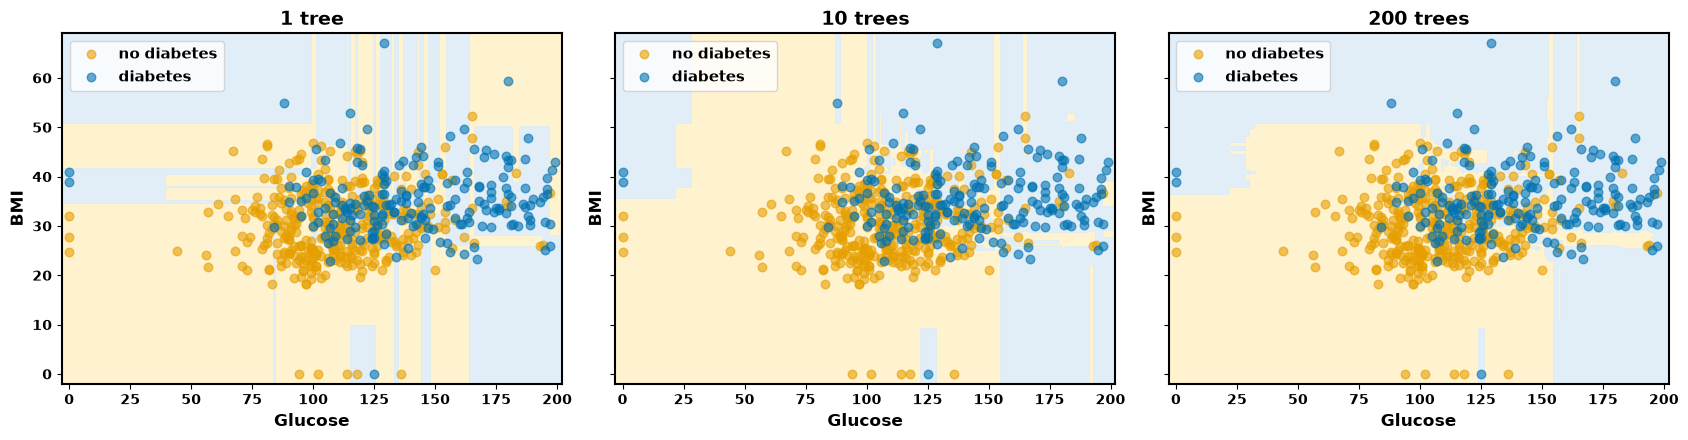

In [22]:
tree_counts = [1, 10, 200]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharex=True, sharey=True)

for number_of_trees, ax in zip(tree_counts, axes):
    model = RandomForestClassifier(
        n_estimators=number_of_trees,
        # Let each tree grow fully so its individual boundary is jagged.
        random_state=90,
    ).fit(X_train, y_train)

    plot_decision_boundary(
        model,
        X_train,
        y_train,
        ax,
        f'{number_of_trees} tree' + ('s' if number_of_trees > 1 else ''),
    )

plt.tight_layout()
plt.show()


## Logistic regression

Despite its name, **logistic regression is used for classification**.

If you're curious, logistic regression is called "regression" because predicts a *probability*, a number between 0 and 1, which we threshold to make classifications. So for example, if the model says that the probability of having diabetes if 0.7, then the probability of not having diabetes is 0.3, so we typically classify that point as diabetes.

The decision boundary for logistic regression is **linear**: with two features, the boundary is a straight line.


### Scaling the features

Glucose and BMI have different units and numerical spreads.

We will standardize both features before fitting logistic regression, keeping the transformation and classifier together with `make_pipeline`.


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logistic = make_pipeline(
    StandardScaler(),
    # max_iter tells sklearn how "long" it should try fitting the model for.
    # Unfortunately the default is usually too short, so we often increase it!
    LogisticRegression(max_iter=10_000),
)
logistic.fit(X_train, y_train)

print('Training accuracy:', logistic.score(X_train, y_train))


Training accuracy: 0.7760416666666666


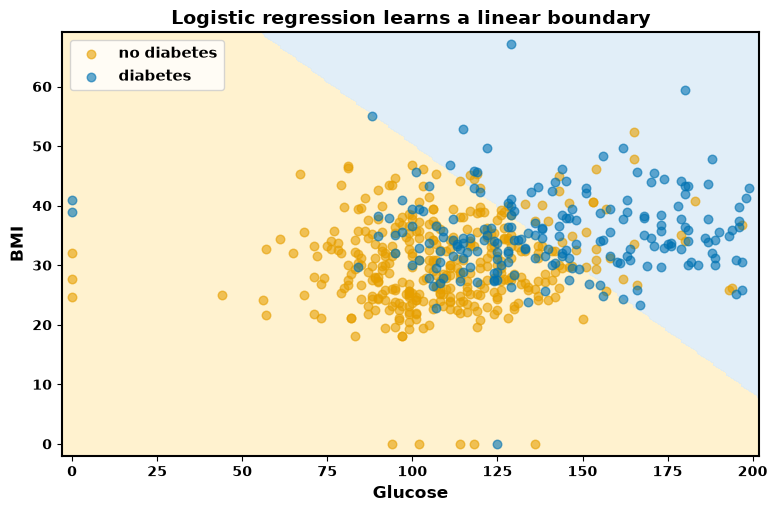

In [24]:
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_decision_boundary(
    logistic, X_train, y_train, ax,
    'Logistic regression learns a linear boundary'
)
plt.show()


## Which classifier should we use?

We now have three model families:

- k-nearest neighbors;
- random forests;
- logistic regression.

We will compare them using the **same training rows and the same five validation folds**.


In [25]:
from sklearn.neighbors import KNeighborsClassifier

models = {
    'k-NN': make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15),
    ),
    'Random forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42,
    ),
    'Logistic regression': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=10_000),
    ),
}


### Comparing what the models learn

All three classifiers use the same two features, but they can learn very different decision boundaries.


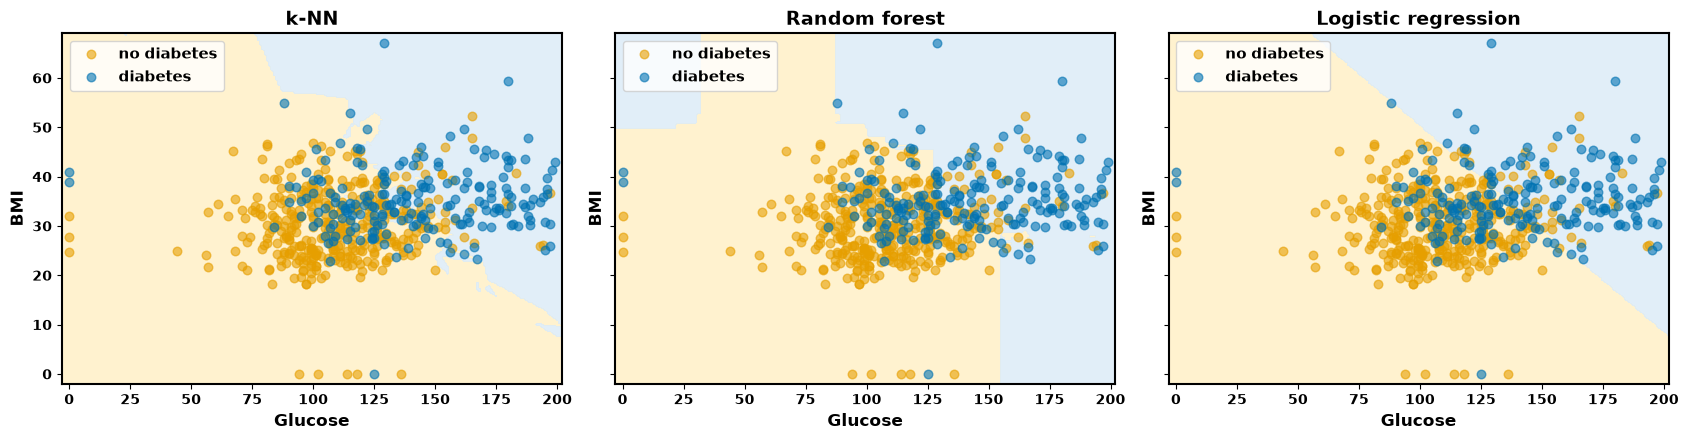

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharex=True, sharey=True)

for (name, model), ax in zip(models.items(), axes):
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X_train, y_train, ax, name)

plt.tight_layout()
plt.show()


## Five-fold model comparison

Each column contains five validation accuracies, one from each fold.


In [27]:
model_scores = {}

for name, model in models.items():
    model_scores[name] = cross_val_score(
        model, X_train, y_train, cv=folds
    )

comparison = pd.DataFrame(
    model_scores,
    index=[f'Fold {i}' for i in range(1, 6)],
)
comparison.loc['Mean'] = comparison.mean()
comparison.loc['SD'] = comparison.iloc[:5].std(ddof=0)
comparison


,k-NN,Random forest,Logistic regression
Fold 1,0.793,0.793,0.793
Fold 2,0.748,0.739,0.765
Fold 3,0.774,0.800,0.817
Fold 4,0.617,0.678,0.687
Fold 5,0.765,0.765,0.774
Mean,0.739,0.755,0.767
SD,0.063,0.044,0.044


In [28]:
mean_scores = comparison.loc['Mean']
chosen_name = mean_scores.idxmax()
final_model = models[chosen_name]

print('Chosen model:', chosen_name)
print('Mean validation accuracy:', mean_scores[chosen_name])


Chosen model: Logistic regression
Mean validation accuracy: 0.7673163418290855


### Choosing a final model

Our rule was to choose the model with the highest mean validation accuracy.

The differences between models are not always meaningful when their fold scores are close. Simplicity, interpretability, and prediction speed can also matter—but we must decide our rule **before** looking at the test score.


## Final evaluation

We have finished selecting the model.

Now that we've committed to our model, we refit the chosen model on ALL training rows (no validation split!) and evaluate it once on the untouched test set.


In [29]:
final_model.fit(X_train, y_train)
final_test_accuracy = final_model.score(X_test, y_test)

print('Final model:', chosen_name)
print(f'Final test accuracy: {final_test_accuracy:.1%}')


Final model: Logistic regression
Final test accuracy: 74.5%


## Takeaways

- Decision trees classify by asking a sequence of questions.
- Tree depth controls complexity and overfitting.
- `GridSearchCV` automates cross-validation over hyperparameter combinations.
- Bootstrap samples are same-sized samples drawn with replacement.
- Random forests combine many randomized decision trees by voting.
- Logistic regression is a linear classifier.
- Compare model families with cross-validation, then evaluate the winner once on the test set.
